In [12]:
# Init

from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
VALIDATION_SIZE = 0.2
N_REPEATS = 10

DATA_DIR = Path("datasets/titanic")
OUTPUT_DIR = Path("outputs/titanic")

NUMERIC_FEATURES = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "HasCabin",
]
CATEGORICAL_FEATURES = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [13]:
# Load

def load_titanic_data(data_dir):
    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = (
        "https://raw.githubusercontent.com/"
        "ageron/handson-ml2/master/datasets/titanic/"
    )

    for filename in ("train.csv", "test.csv"):
        path = data_dir / filename

        if not path.is_file():
            urlretrieve(base_url + filename, str(path))

    train_df = pd.read_csv(data_dir / "train.csv")
    test_df = pd.read_csv(data_dir / "test.csv")

    return train_df, test_df

train_df, test_df = load_titanic_data(DATA_DIR)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
# Data splitting

X_full = train_df.drop(columns="Survived")
y_full = train_df["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=VALIDATION_SIZE, stratify=y_full, random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_val.shape)

(712, 11)
(179, 11)


In [15]:
# First Analyze

X_train.info()

summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing": X_train.isnull().sum(),
    "missing_fraction": X_train.isna().mean(),
    "unique_values": X_train.nunique(),
})

summary

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Sex          712 non-null    str    
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    str    
 10  Embarked     710 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 66.8 KB


,dtype,missing,missing_fraction,unique_values
PassengerId,int64,0,0.000000,712
Pclass,int64,0,0.000000,3
Name,str,0,0.000000,712
Sex,str,0,0.000000,2
Age,float64,137,0.192416,85
SibSp,int64,0,0.000000,7
Parch,int64,0,0.000000,7
Ticket,str,0,0.000000,571
Fare,float64,0,0.000000,226
Cabin,str,552,0.775281,127


In [16]:
# More Splitting

target_distribution = pd.DataFrame({
    "count": y_train.value_counts(),
    "fraction": y_train.value_counts(normalize=True),
}).sort_index()

target_distribution

,count,fraction
Survived,,
0,439,0.616573
1,273,0.383427


In [17]:
# Features

def add_features(df):
    res = df.copy()

    title = (
        res["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    )

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    res["Title"] = title.where(title.isin(common_titles), "Rare")
    res["HasCabin"] = (res["Cabin"].notna().astype(int))

    return res

add_features(X_train)[
    ["Name", "Title", "Cabin", "HasCabin"]
].head()

,Name,Title,Cabin,HasCabin
692,"Lam, Mr. Ali",Mr,NaN,0
481,"Frost, Mr. Anthony Wood 'Archie'",Mr,NaN,0
527,"Farthing, Mr. John",Mr,C95,1
855,"Aks, Mrs. Sam (Leah Rosen)",Mrs,NaN,0
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",Mrs,NaN,0


In [18]:
# Pipeline

def build_model(classifier):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    return Pipeline([
        ("features", FunctionTransformer(add_features, validate=False)),
        ("preprocessing", preprocessor),
        ("classifier", clone(classifier)),
    ])

In [19]:
# CV

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

cv_splits = list(cv.split(X_train, y_train))
print(len(cv_splits))

50


In [30]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "svc": SVC(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1,),
    "gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "cat_boost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, thread_count=1,),
    "light_gbm": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
    "xgboost": XGBClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
}

cv_scores = {}
rows = []

for name, classifier in classifiers.items():
    candidate = build_model(classifier)

    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv_splits,
        scoring="accuracy",
        n_jobs=-1,
        error_score="raise",
    )

    cv_scores[name] = scores

    rows.append({"model": name, "mean_accuracy": scores.mean(), "std_accuracy": scores.std()})

comparison = (pd.DataFrame(rows).set_index("model").sort_values("mean_accuracy", ascending=False))

print(comparison.round(4))

                     mean_accuracy  std_accuracy
model                                           
cat_boost                   0.8296        0.0301
svc                         0.8274        0.0279
logistic_regression         0.8266        0.0322
gradient_boosting           0.8219        0.0326
light_gbm                   0.8177        0.0372
random_forest               0.8146        0.0314
xgboost                     0.8053        0.0366
dummy                       0.6166        0.0027


In [40]:
# Searching for Parameters

selected_name = (comparison.drop(index="dummy").index[0])

parameters_grids = {
    "logistic_regression": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
    },
    "svc": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__gamma": ["scale", 0.01],
        "classifier__kernel": ["rbf"],
    },
    "random_forest": {
        "classifier__max_depth": [6, None],
        "classifier__min_samples_leaf": [1, 3],
    },
    "gradient_boosting": {
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_iter": [100, 200],
        "classifier__max_leaf_nodes": [7, 15, 31],
        "classifier__min_samples_leaf": [10, 20, 30],
        "classifier__l2_regularization": [0.0, 1.0],
    },
    "cat_boost": {
        "classifier__iterations": [300, 700],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__depth": [4, 6, 8],
        "classifier__l2_leaf_reg": [1, 3, 10],
    },
    "light_gbm": {
        "classifier__n_estimators": [100, 300],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__num_leaves": [7, 15, 31],
        "classifier__max_depth": [3, 5, -1],
        "classifier__min_child_samples": [10, 20, 30],
    },
    "xgboost": {
        "classifier__n_estimators": [100, 300],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [2, 4, 6],
        "classifier__min_child_weight": [1, 3, 5],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
    },
}

search = GridSearchCV(
    estimator=build_model(classifiers[selected_name]),
    param_grid=parameters_grids[selected_name],
    scoring="accuracy",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

search.fit(X_train, y_train)

print(selected_name)
print(search.best_params_)
print(search.best_score_)

selected_model = search.best_estimator_

cat_boost
{'classifier__depth': 4, 'classifier__iterations': 700, 'classifier__l2_leaf_reg': 3, 'classifier__learning_rate': 0.03}
0.8351127745493944


Validation accuracy: 0.8156
              precision    recall  f1-score   support

           0      0.835     0.873     0.853       110
           1      0.781     0.725     0.752        69

    accuracy                          0.816       179
   macro avg      0.808     0.799     0.803       179
weighted avg      0.814     0.816     0.814       179



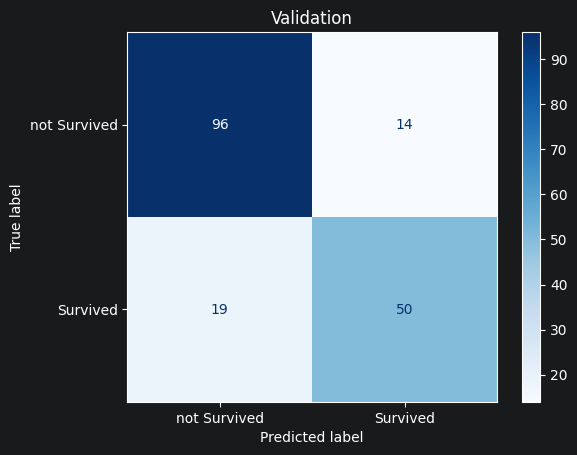

In [34]:
# Grading Model

val_predictions = selected_model.predict(X_val)

validation_accuracy = accuracy_score(y_val, val_predictions)

print(f"Validation accuracy: {validation_accuracy:.4f}")

print(classification_report(y_val, val_predictions, digits=3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_val, val_predictions, display_labels=["not Survived", "Survived"], cmap="Blues")
plt.title("Validation")
plt.show()

In [35]:
# Analyzing Model Errors

validation_details = add_features(X_val)

validation_details["actual"] = y_val
validation_details["predictions"] = val_predictions

errors = validation_details.loc[
    validation_details["actual"] != validation_details["predictions"]
].copy()

print("errors: ", len(errors))

errors[[
    "PassengerId",
    "Sex",
    "Age",
    "Pclass",
    "Title",
    "HasCabin",
    "actual",
    "predictions",
]].head(15)

errors:  33


,PassengerId,Sex,Age,Pclass,Title,HasCabin,actual,predictions
553,554,male,22.0,3,Mr,0,1,0
559,560,female,36.0,3,Mrs,0,1,0
536,537,male,45.0,1,Rare,1,0,1
698,699,male,49.0,1,Mr,1,0,1
216,217,female,27.0,3,Miss,0,1,0
279,280,female,35.0,3,Mrs,0,1,0
712,713,male,48.0,1,Mr,1,1,0
455,456,male,29.0,3,Mr,0,1,0
489,490,male,9.0,3,Master,0,1,0
165,166,male,9.0,3,Master,0,1,0


In [1]:
# Final Model

final_model = clone(selected_model)

final_model.fit(X_full, y_full)

NameError: name 'clone' is not defined

In [37]:
# Predictions on test.csv

test_predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions.astype(int),
})

assert len(submission) == len(test_df)
assert submission["PassengerId"].equals(test_df["PassengerId"])
assert submission["Survived"].isin([0, 1]).all()
assert not submission.isna().any().any()

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [38]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

submission_path = OUTPUT_DIR / "submission.csv"

submission.to_csv(OUTPUT_DIR / "model_comparison.csv")

pd.DataFrame(cv_scores).to_csv(OUTPUT_DIR / "cv_scores.csv", index=False)

print("Done")

Done


In [39]:
# Submission for Kaggle

from pathlib import Path
from sklearn.base import clone
import pandas as pd

final_model = clone(selected_model)
final_model.fit(X_full, y_full)

predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions.astype(int),
})

assert submission.shape == (418, 2)
assert not submission.isna().any().any()
assert submission["Survived"].isin([0, 1]).all()

submission_path = Path("outputs/titanic/submission.csv")
submission_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(submission_path, index=False)

print("File:", submission_path.resolve())

File: /home/kolja/home/kole4ka_bot/first-ml-project/training/titanic/outputs/titanic/submission.csv
